# Final Table And Object Integration

This notebook builds the final table and integrates detections into object IDs.

In [1]:
from pathlib import Path
from types import SimpleNamespace
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
from final_table import build_final_table
from object_integration import integrate_objects
from IPython.display import display
from visualize_dbscan import plot_static_clusters, summarize_registry


In [2]:
final_args = SimpleNamespace(
    input_csv=config.PROJECTED_DETECTIONS_CSV,
    output_csv=config.FINAL_TABLE_CSV,
    timestamp_lookup_csv=config.TIMESTAMP_LOOKUP_CSV,
)

final_rows = build_final_table(final_args)
len(final_rows), final_rows[:2]

Final table: 100%|██████████| 77343/77343 [00:16<00:00, 4649.18object/s]


(77343,
 [{'image_name': 'IR_57327.jpg',
   'timestamp': '2025-04-23 13:28:31',
   'detection_index': '1',
   'label': 'Person',
   'confidence': '0.874230',
   'bbox_x0': '387.652466',
   'bbox_y0': '222.652374',
   'bbox_x1': '577.045776',
   'bbox_y1': '487.564484',
   'projected_x': '11.736513',
   'projected_y': '4.481120',
   'projection_model': 'human',
   'temp_mean_c': '27.347015',
   'temp_max_c': '34.000000',
   'source_image_path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/thermal_images/IR_57327.jpg',
   'preprocessed_image_path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/preprocessed/images/IR_57327.png',
   'temperature_map_path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/preprocessed/temperature_maps/IR_57327.npy',
   'annotated_image_path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/yolo/annotated_images/IR_57327_pred.jpg',
   'scale_top': '34.0',
   'scale_bottom

## DBSCAN

Run global DBSCAN clustering, then plot the learned anchors.


In [21]:
DBSCAN_EPS = 0.30
DBSCAN_MIN_SAMPLES = 8

dbscan_args = SimpleNamespace(
    input_csv=config.FINAL_TABLE_CSV,
    output_csv=config.INTEGRATED_OBJECTS_CSV,
    registry_csv=config.STATIC_OBJECT_REGISTRY_CSV,
    frame_iou_threshold=0.35,
    frame_projected_distance_threshold=0.50,
    track_distance_threshold=0.60,
    track_person=False,
    static_clustering='dbscan',
    dbscan_eps=DBSCAN_EPS,
    dbscan_min_samples=DBSCAN_MIN_SAMPLES,
)

raw_rows, deduped_rows, dbscan_rows, dbscan_registry = integrate_objects(dbscan_args)
{
    'method': 'dbscan',
    'dbscan_eps': DBSCAN_EPS,
    'dbscan_min_samples': DBSCAN_MIN_SAMPLES,
    'raw_rows': len(raw_rows),
    'deduped_rows': len(deduped_rows),
    'integrated_rows': len(dbscan_rows),
    'static_objects': len(dbscan_registry),
}


{'method': 'dbscan',
 'dbscan_eps': 0.3,
 'dbscan_min_samples': 8,
 'raw_rows': 77343,
 'deduped_rows': 69933,
 'integrated_rows': 69933,
 'static_objects': 10}

Plotted DBSCAN anchors: 10
/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/integration/dbscan_global_preview.png


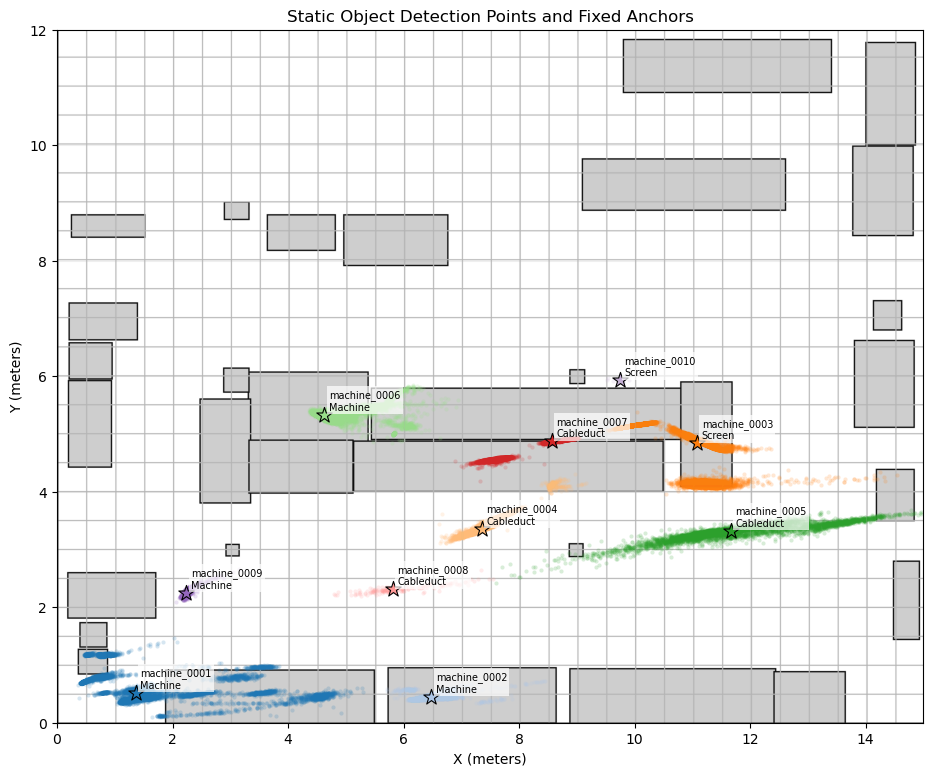

In [22]:
LABEL_FILTER = None
MAX_POINTS = None

fig, ax, plotted_anchors = plot_static_clusters(
    integrated_csv=config.INTEGRATED_OBJECTS_CSV,
    registry_csv=config.STATIC_OBJECT_REGISTRY_CSV,
    layout_path=config.LAYOUT_IMAGE,
    label_filter=LABEL_FILTER,
    max_points=MAX_POINTS,
)
preview_path = config.INTEGRATION_OUTPUT_DIR / 'dbscan_global_preview.png'
fig.savefig(preview_path, dpi=140, bbox_inches='tight')
print(f"Plotted DBSCAN anchors: {len(plotted_anchors)}")
print(preview_path)
#display(fig)


## KMeans

Run global KMeans clustering with a fixed cluster count, then plot the learned anchors.


In [25]:
KMEANS_CLUSTERS = 16
KMEANS_RANDOM_STATE = 12345

kmeans_args = SimpleNamespace(
    input_csv=config.FINAL_TABLE_CSV,
    output_csv=config.INTEGRATED_OBJECTS_CSV,
    registry_csv=config.STATIC_OBJECT_REGISTRY_CSV,
    frame_iou_threshold=0.35,
    frame_projected_distance_threshold=0.50,
    track_distance_threshold=0.60,
    track_person=False,
    static_clustering='kmeans',
    kmeans_clusters=KMEANS_CLUSTERS,
    kmeans_random_state=KMEANS_RANDOM_STATE,
)

raw_rows, deduped_rows, kmeans_rows, kmeans_registry = integrate_objects(kmeans_args)
{
    'method': 'kmeans',
    'kmeans_clusters': KMEANS_CLUSTERS,
    'kmeans_random_state': KMEANS_RANDOM_STATE,
    'raw_rows': len(raw_rows),
    'deduped_rows': len(deduped_rows),
    'integrated_rows': len(kmeans_rows),
    'static_objects': len(kmeans_registry),
}


{'method': 'kmeans',
 'kmeans_clusters': 16,
 'kmeans_random_state': 12345,
 'raw_rows': 77343,
 'deduped_rows': 69933,
 'integrated_rows': 69933,
 'static_objects': 16}

Plotted KMeans anchors: 16
/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/integration/kmeans_global_preview.png


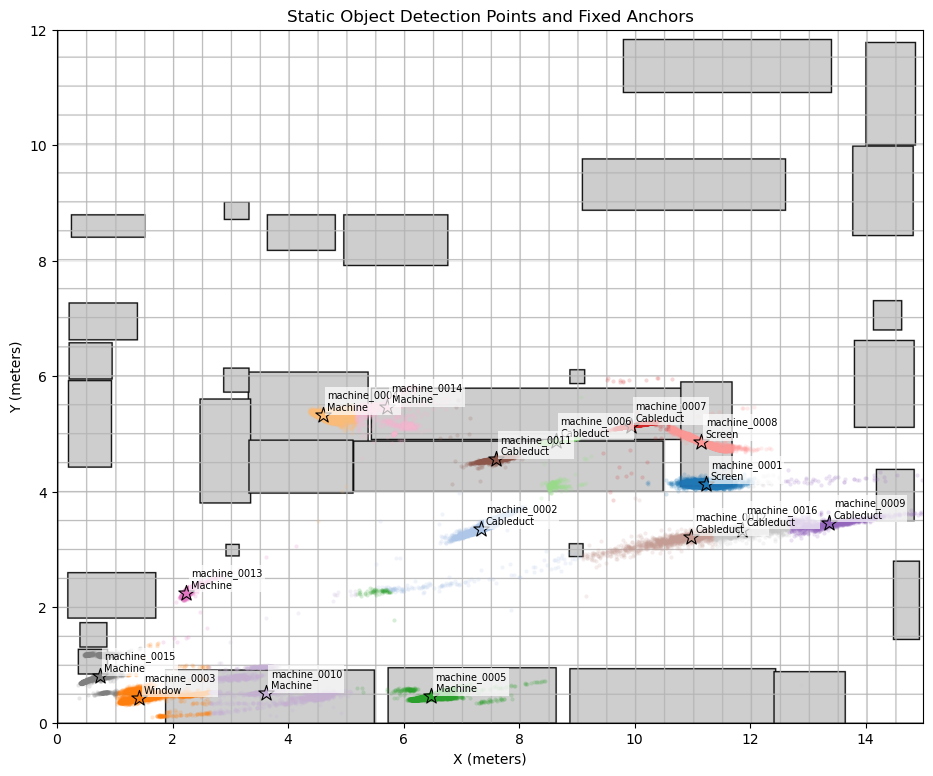

In [26]:
LABEL_FILTER = None
MAX_POINTS = None

fig, ax, plotted_anchors = plot_static_clusters(
    integrated_csv=config.INTEGRATED_OBJECTS_CSV,
    registry_csv=config.STATIC_OBJECT_REGISTRY_CSV,
    layout_path=config.LAYOUT_IMAGE,
    label_filter=LABEL_FILTER,
    max_points=MAX_POINTS,
)
preview_path = config.INTEGRATION_OUTPUT_DIR / 'kmeans_global_preview.png'
fig.savefig(preview_path, dpi=140, bbox_inches='tight')
print(f"Plotted KMeans anchors: {len(plotted_anchors)}")
print(preview_path)
#display(fig)


## GMM

Run global GMM clustering with BIC model selection, then plot the learned anchors.


In [7]:
GMM_MAX_COMPONENTS = 16
GMM_RANDOM_STATE = 42

gmm_args = SimpleNamespace(
    input_csv=config.FINAL_TABLE_CSV,
    output_csv=config.INTEGRATED_OBJECTS_CSV,
    registry_csv=config.STATIC_OBJECT_REGISTRY_CSV,
    frame_iou_threshold=0.35,
    frame_projected_distance_threshold=0.50,
    track_distance_threshold=0.60,
    track_person=False,
    static_clustering='gmm',
    gmm_max_components=GMM_MAX_COMPONENTS,
    gmm_random_state=GMM_RANDOM_STATE,
)

raw_rows, deduped_rows, gmm_rows, gmm_registry = integrate_objects(gmm_args)
{
    'method': 'gmm',
    'gmm_max_components': GMM_MAX_COMPONENTS,
    'gmm_random_state': GMM_RANDOM_STATE,
    'raw_rows': len(raw_rows),
    'deduped_rows': len(deduped_rows),
    'integrated_rows': len(gmm_rows),
    'static_objects': len(gmm_registry),
}


{'method': 'gmm',
 'gmm_max_components': 16,
 'gmm_random_state': 42,
 'raw_rows': 77343,
 'deduped_rows': 69933,
 'integrated_rows': 69933,
 'static_objects': 16}

Plotted GMM anchors: 16
/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/integration/gmm_global_preview.png


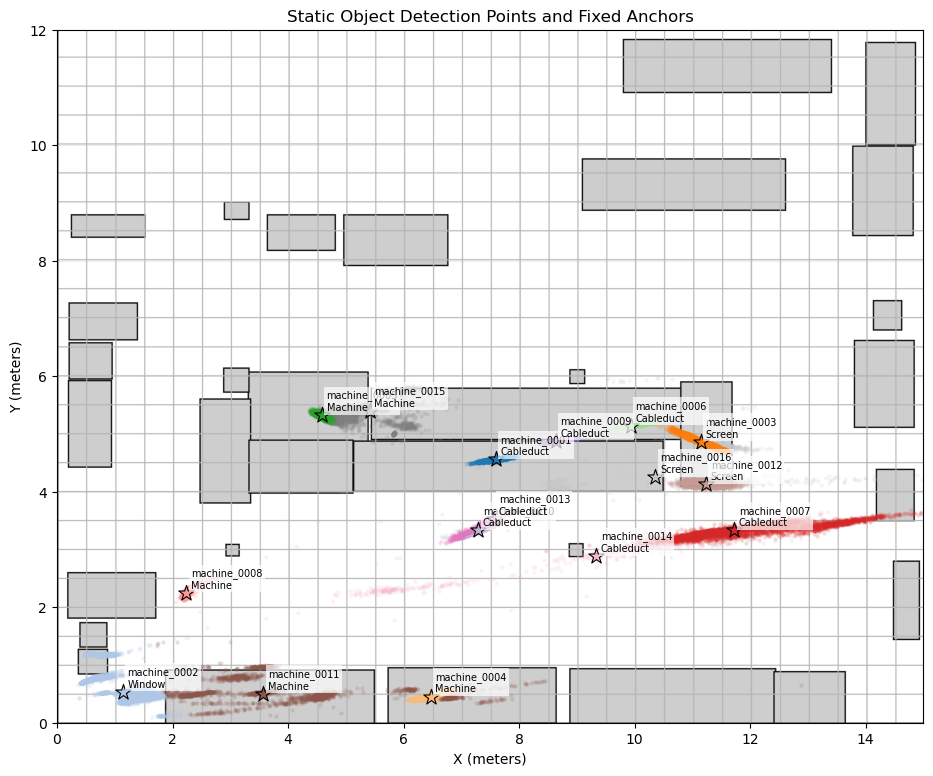

In [8]:
LABEL_FILTER = None
MAX_POINTS = None

fig, ax, plotted_anchors = plot_static_clusters(
    integrated_csv=config.INTEGRATED_OBJECTS_CSV,
    registry_csv=config.STATIC_OBJECT_REGISTRY_CSV,
    layout_path=config.LAYOUT_IMAGE,
    label_filter=LABEL_FILTER,
    max_points=MAX_POINTS,
)
preview_path = config.INTEGRATION_OUTPUT_DIR / 'gmm_global_preview.png'
fig.savefig(preview_path, dpi=140, bbox_inches='tight')
print(f"Plotted GMM anchors: {len(plotted_anchors)}")
print(preview_path)
#display(fig)
